# Phase 2B: temporal relational-change diagnostics

## Purpose and limits

This descriptive diagnostic asks whether the **separate typed relational channels** established in Phase 2A can show defensive organization changing through time. It does not combine channels, assign states, detect change points, optimize lags, or define relational weights.

The seven windows and relationship selections are copied exactly from Phase 2A. Raw geometric levels are shown first. When rates are useful, coordinates or pairwise quantities are smoothed with a centered 7-frame rolling mean at 25 Hz (0.28 s), with fixed 5/7/9-frame sensitivity. A full window is required; centered finite differences add one undefined frame at each valid segment edge. Missing tracking values are not interpolated.

Temporal precedence is descriptive only. An earlier visible change cannot establish cause, responsibility, instruction, or intent.

In [1]:
from pathlib import Path
import hashlib, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
DATA=ROOT/'data'/'metrica_sample_game_1'
HOME_PATH=DATA/'Sample_Game_1_RawTrackingData_Home_Team.csv'
AWAY_PATH=DATA/'Sample_Game_1_RawTrackingData_Away_Team.csv'
EVENT_PATH=DATA/'Sample_Game_1_RawEventsData.csv'
LENGTH,WIDTH,FPS=105.,68.,25.

def sha256(path):
    h=hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''): h.update(block)
    return h.hexdigest()

display(pd.DataFrame({'file':[p.name for p in (HOME_PATH,AWAY_PATH,EVENT_PATH)],'sha256':[sha256(p) for p in (HOME_PATH,AWAY_PATH,EVENT_PATH)]}))

,file,sha256
0,Sample_Game_1_RawTrackingData_Home_Team.csv,0a3d0eff7785950379c587d3597b86a2d91c2492281b46...
1,Sample_Game_1_RawTrackingData_Away_Team.csv,0a3df68a92af0290ede472e62de3b6489ddee29223da09...
2,Sample_Game_1_RawEventsData.csv,097dda6345e17390dca095331458fd00e47960c480c76f...


In [2]:
def load_tracking(path,team):
    h=pd.read_csv(path,header=None,nrows=3)
    ids=[str(int(float(v))) for v in h.iloc[1,3:-2:2] if pd.notna(v)]
    cols=['Period','Frame','Time [s]']
    for pid in ids: cols += [f'{team}_{pid}_x',f'{team}_{pid}_y']
    cols += [f'{team}_ball_x',f'{team}_ball_y']
    return pd.read_csv(path,skiprows=3,names=cols),ids

home,hp=load_tracking(HOME_PATH,'Home'); away,ap=load_tracking(AWAY_PATH,'Away'); events=pd.read_csv(EVENT_PATH)
tracking={'Home':home,'Away':away}; players={'Home':hp,'Away':ap}; goalkeeper={'Home':'11','Away':'25'}
print({'Home':home.shape,'Away':away.shape,'events':events.shape})

{'Home': (145006, 33), 'Away': (145006, 33), 'events': (1745, 14)}


## Fixed Phase 2A cases and windows

No case was added, removed, shifted, or replaced after inspecting temporal quantities. For cases without a prior fixed local subset, the same focal-plus-two-nearest-at-window-start display rule from Phase 2A is reused. This is not a tactical unit or assignment.

In [3]:
CASES=[
 {'name':'coordinated collective movement','source':'Phase 1A','period':1,'start':1888.0,'end':1896.0,'def_team':'Home','focal':'2','opp_team':'Away','opponent':None,'selected_defs':None,'secondary_opponents':[]},
 {'name':'apparent individual excursion','source':'Phase 1A/1D','period':1,'start':590.0,'end':598.0,'def_team':'Home','focal':'2','opp_team':'Away','opponent':'23','selected_defs':None,'secondary_opponents':[]},
 {'name':'tackle / engagement','source':'Phase 1C/1E','period':1,'start':550.76,'end':555.76,'def_team':'Away','focal':'16','opp_team':'Home','opponent':'9','selected_defs':None,'secondary_opponents':[]},
 {'name':'primary interior-threat anchor','source':'Phase 1F','period':1,'start':1228.12,'end':1232.12,'def_team':'Away','focal':'19','opp_team':'Home','opponent':'10','selected_defs':['19','20','21'],'secondary_opponents':['6','7','5'],'anchor':1230.12},
 {'name':'collective accommodation / engagement','source':'Phase 1E','period':1,'start':1229.28,'end':1234.28,'def_team':'Away','focal':'19','opp_team':'Home','opponent':'10','selected_defs':['19','20','21'],'secondary_opponents':['6','7','5'],'anchor':1232.28},
 {'name':'collective-translation contrast','source':'Phase 1E','period':2,'start':3679.88,'end':3684.88,'def_team':'Home','focal':'8','opp_team':'Away','opponent':'15','selected_defs':None,'secondary_opponents':[],'anchor':3682.88},
 {'name':'negative interior-threat case','source':'Phase 1F','period':2,'start':4195.04,'end':4199.04,'def_team':'Away','focal':'16','opp_team':'Home','opponent':'10','selected_defs':['16','18','21'],'secondary_opponents':['12','6','3'],'anchor':4197.04},
]
display(pd.DataFrame(CASES)[['name','period','start','end','def_team','focal','opp_team','opponent']])

,name,period,start,end,def_team,focal,opp_team,opponent
0,coordinated collective movement,1,1888.00,1896.00,Home,2,Away,None
1,apparent individual excursion,1,590.00,598.00,Home,2,Away,23
2,tackle / engagement,1,550.76,555.76,Away,16,Home,9
3,primary interior-threat anchor,1,1228.12,1232.12,Away,19,Home,10
4,collective accommodation / engagement,1,1229.28,1234.28,Away,19,Home,10
5,collective-translation contrast,2,3679.88,3684.88,Home,8,Away,15
6,negative interior-threat case,2,4195.04,4199.04,Away,16,Home,10


In [4]:
def case_window(case):
    d=tracking[case['def_team']]; o=tracking[case['opp_team']]
    w=d[(d.Period==case['period'])&d['Time [s]'].between(case['start'],case['end'])].copy()
    cols=['Frame']+[f"{case['opp_team']}_{p}_{a}" for p in players[case['opp_team']] for a in ('x','y')]
    return w.merge(o[cols],on='Frame',validate='one_to_one')

def outfield(case): return [p for p in players[case['def_team']] if p!=goalkeeper[case['def_team']]]
def xy(row,team,p): return np.array([row[f'{team}_{p}_x']*LENGTH,row[f'{team}_{p}_y']*WIDTH],float)

def nearest_ids(case,w,count=3):
    if case['selected_defs']: return case['selected_defs']
    r=w.iloc[0]; fxy=xy(r,case['def_team'],case['focal']); vals=[]
    for p in outfield(case):
        if p==case['focal']: continue
        pxy=xy(r,case['def_team'],p)
        if np.isfinite(pxy).all(): vals.append((np.linalg.norm(pxy-fxy),p))
    return [case['focal']]+[p for _,p in sorted(vals)[:count-1]]

def add_base(case):
    w=case_window(case); dt=case['def_team']; ids=outfield(case); refs=[p for p in ids if p!=case['focal']]
    w['centroid_x_m']=w[[f'{dt}_{p}_x' for p in ids]].mean(axis=1)*LENGTH
    w['centroid_y_m']=w[[f'{dt}_{p}_y' for p in ids]].mean(axis=1)*WIDTH
    w['loo_x_m']=w[[f'{dt}_{p}_x' for p in refs]].mean(axis=1)*LENGTH
    w['loo_y_m']=w[[f'{dt}_{p}_y' for p in refs]].mean(axis=1)*WIDTH
    w['focal_loo_x_m']=w[f'{dt}_{case["focal"]}_x']*LENGTH-w['loo_x_m']
    w['focal_loo_y_m']=w[f'{dt}_{case["focal"]}_y']*WIDTH-w['loo_y_m']
    w['plot_t']=w['Time [s]']-(case.get('anchor') if case.get('anchor') is not None else case['start'])
    return w

def smooth_rate(values,time,window=7):
    smooth=pd.Series(values,index=time.index).rolling(window,center=True,min_periods=window).mean()
    rate=(smooth.shift(-1)-smooth.shift(1))/(time.shift(-1)-time.shift(1))
    return smooth,rate

for case in CASES:
    w=add_base(case); case['display_defs']=nearest_ids(case,w)
    print(case['name'],len(w),'frames',case['display_defs'])

coordinated collective movement 201 frames ['2', '3', '7']
apparent individual excursion 201 frames ['2', '3', '1']
tackle / engagement 126 frames ['16', '17', '15']
primary interior-threat anchor 101 frames ['19', '20', '21']
collective accommodation / engagement 126 frames ['19', '20', '21']
collective-translation contrast 126 frames ['8', '10', '5']
negative interior-threat case 101 frames ['16', '18', '21']


## Primary worked example: 1230.12 s

The snapshots and aligned raw-level plots below make every temporal reading traceable to the pitch. The event anchor is a time reference, not a behavioral label.

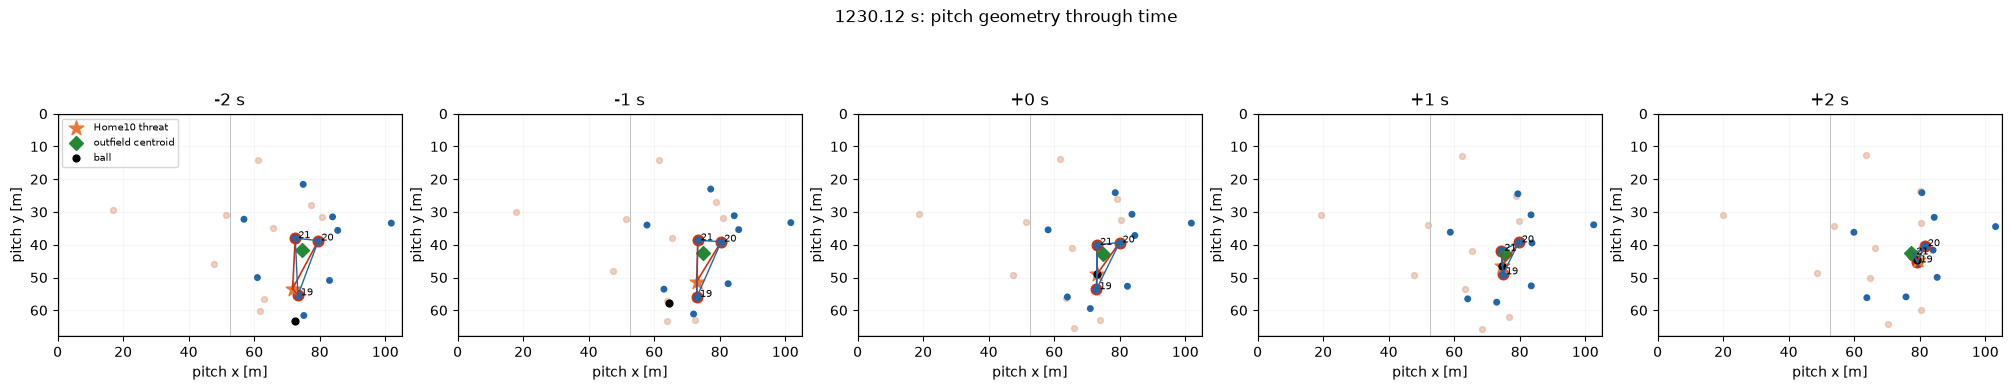

In [5]:
PRIMARY=next(x for x in CASES if x['name']=='primary interior-threat anchor')
def pitch(ax):
    ax.plot([0,LENGTH,LENGTH,0,0],[0,0,WIDTH,WIDTH,0],c='0.35',lw=1); ax.axvline(LENGTH/2,c='0.75',lw=.7)
    ax.set(xlim=(0,LENGTH),ylim=(WIDTH,0),aspect='equal',xlabel='pitch x [m]',ylabel='pitch y [m]'); ax.grid(alpha=.1)
def nearest_row(w,target): return w.loc[(w['Time [s]']-target).abs().idxmin()]

def primary_snapshots(case):
    w=add_base(case); dt,ot=case['def_team'],case['opp_team']; offsets=[-2,-1,0,1,2]
    fig,axes=plt.subplots(1,5,figsize=(20,4),constrained_layout=True)
    for ax,off in zip(axes,offsets):
        r=nearest_row(w,case['anchor']+off); pitch(ax)
        for p in players[ot]: ax.scatter(*xy(r,ot,p),c='#dd9977',s=18,alpha=.45)
        for p in players[dt]:
            emph=p in case['display_defs']; ax.scatter(*xy(r,dt,p),c='#2266aa',s=52 if emph else 25,edgecolor='#cc3311' if emph else 'none',linewidth=1.4)
            if emph: ax.text(*xy(r,dt,p),f' {p}',fontsize=7)
        threat=xy(r,ot,case['opponent']); ax.scatter(*threat,c='#ee7733',marker='*',s=120,label='Home10 threat')
        for p in case['display_defs']:
            d=xy(r,dt,p); ax.plot([d[0],threat[0]],[d[1],threat[1]],c='#cc3311',lw=1.2)
        for p,q in itertools.combinations(case['display_defs'],2):
            a,b=xy(r,dt,p),xy(r,dt,q); ax.plot([a[0],b[0]],[a[1],b[1]],c='#2266aa',lw=1)
        ax.scatter(r['centroid_x_m'],r['centroid_y_m'],c='#228833',marker='D',s=50,label='outfield centroid')
        ax.scatter(r[f'{dt}_ball_x']*LENGTH,r[f'{dt}_ball_y']*WIDTH,c='black',s=24,label='ball')
        ax.set_title(f'{off:+d} s')
    axes[0].legend(fontsize=7,loc='upper left'); fig.suptitle('1230.12 s: pitch geometry through time',y=1.04); plt.show()
primary_snapshots(PRIMARY)

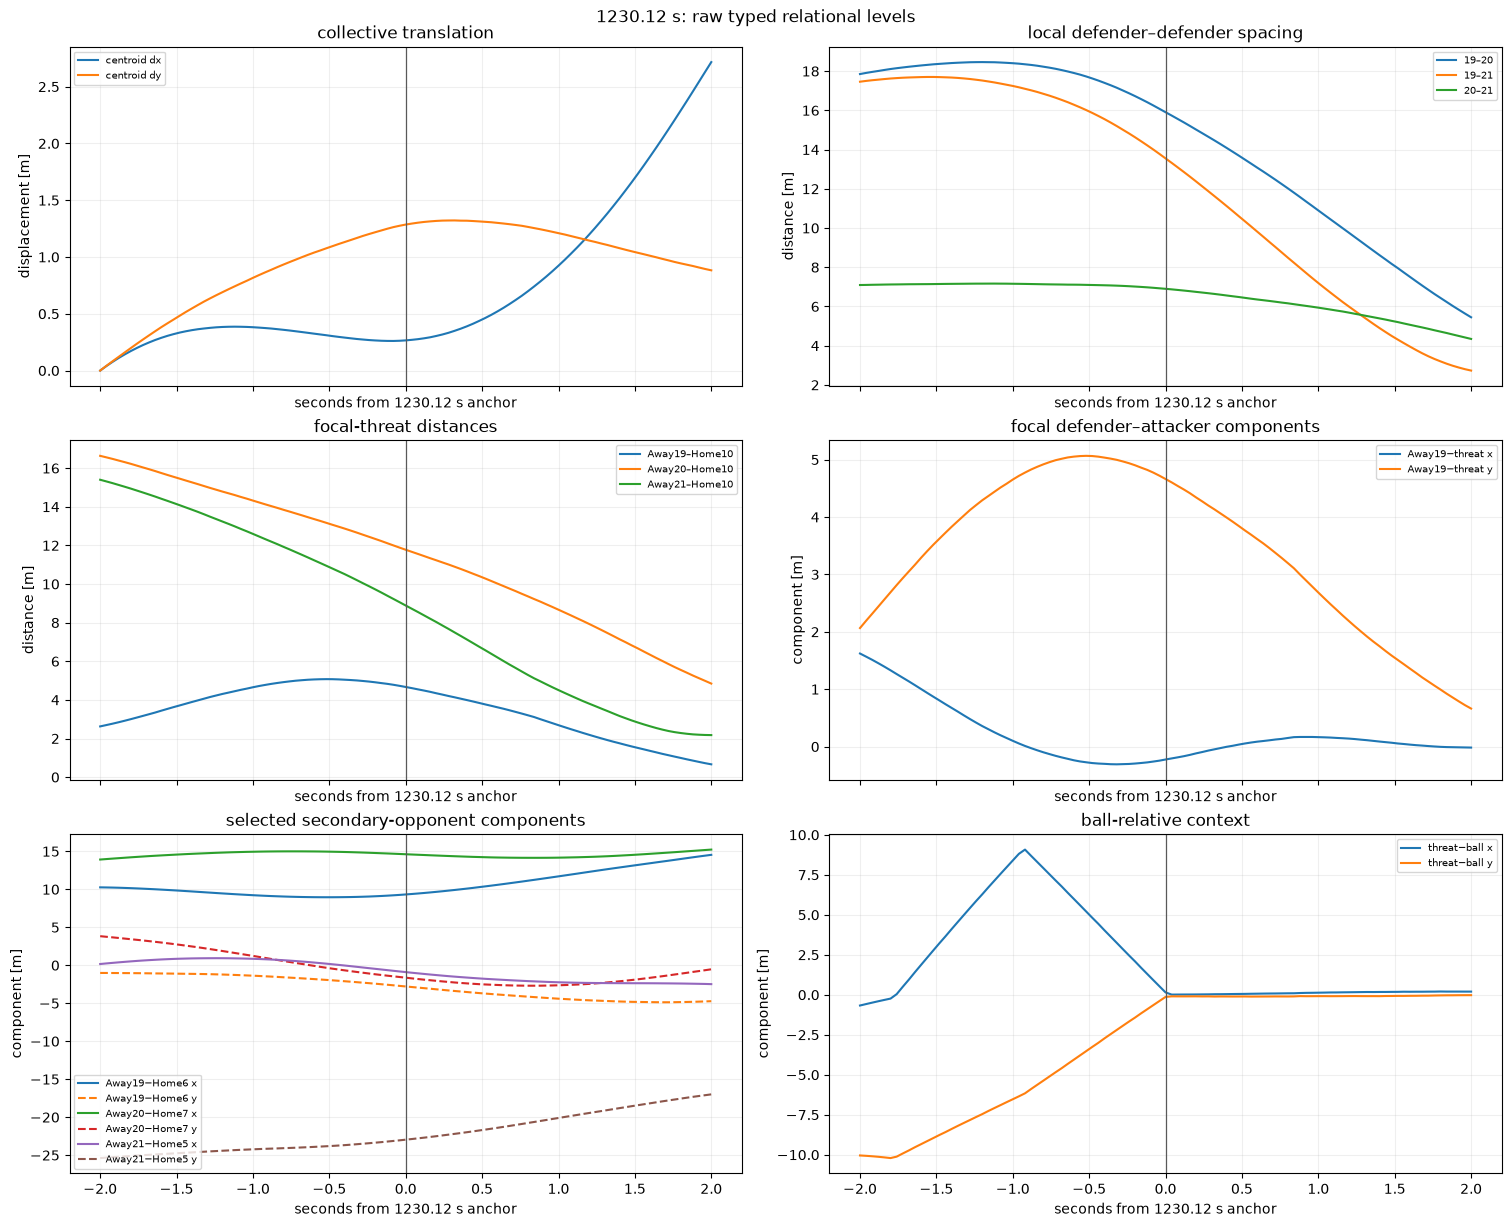

In [6]:
def primary_levels(case):
    w=add_base(case); dt,ot=case['def_team'],case['opp_team']; t=w['plot_t']; defs=case['display_defs']
    fig,axes=plt.subplots(3,2,figsize=(15,12),sharex=True,constrained_layout=True)
    ax=axes[0,0]; ax.plot(t,w.centroid_x_m-w.centroid_x_m.iloc[0],label='centroid dx'); ax.plot(t,w.centroid_y_m-w.centroid_y_m.iloc[0],label='centroid dy'); ax.set_title('collective translation'); ax.set_ylabel('displacement [m]')
    ax=axes[0,1]
    for p,q in itertools.combinations(defs,2):
        d=np.hypot((w[f'{dt}_{p}_x']-w[f'{dt}_{q}_x'])*LENGTH,(w[f'{dt}_{p}_y']-w[f'{dt}_{q}_y'])*WIDTH); ax.plot(t,d,label=f'{p}–{q}')
    ax.set_title('local defender–defender spacing'); ax.set_ylabel('distance [m]')
    ax=axes[1,0]
    for p in defs:
        d=np.hypot((w[f'{dt}_{p}_x']-w[f'{ot}_{case["opponent"]}_x'])*LENGTH,(w[f'{dt}_{p}_y']-w[f'{ot}_{case["opponent"]}_y'])*WIDTH); ax.plot(t,d,label=f'{dt}{p}–{ot}{case["opponent"]}')
    ax.set_title('focal-threat distances'); ax.set_ylabel('distance [m]')
    ax=axes[1,1]; p=case['focal']
    ax.plot(t,(w[f'{dt}_{p}_x']-w[f'{ot}_{case["opponent"]}_x'])*LENGTH,label=f'{dt}{p}−threat x'); ax.plot(t,(w[f'{dt}_{p}_y']-w[f'{ot}_{case["opponent"]}_y'])*WIDTH,label=f'{dt}{p}−threat y'); ax.set_title('focal defender–attacker components'); ax.set_ylabel('component [m]')
    ax=axes[2,0]
    for p,a in zip(defs,case['secondary_opponents']):
        ax.plot(t,(w[f'{dt}_{p}_x']-w[f'{ot}_{a}_x'])*LENGTH,label=f'{dt}{p}−{ot}{a} x')
        ax.plot(t,(w[f'{dt}_{p}_y']-w[f'{ot}_{a}_y'])*WIDTH,ls='--',label=f'{dt}{p}−{ot}{a} y')
    ax.set_title('selected secondary-opponent components'); ax.set_ylabel('component [m]')
    ax=axes[2,1]; bx=w[f'{dt}_ball_x']*LENGTH; by=w[f'{dt}_ball_y']*WIDTH
    ax.plot(t,w[f'{ot}_{case["opponent"]}_x']*LENGTH-bx,label='threat−ball x'); ax.plot(t,w[f'{ot}_{case["opponent"]}_y']*WIDTH-by,label='threat−ball y'); ax.set_title('ball-relative context'); ax.set_ylabel('component [m]')
    for ax in axes.flat:
        ax.axvline(0,c='0.35',lw=.9); ax.grid(alpha=.2); ax.legend(fontsize=7); ax.set_xlabel('seconds from 1230.12 s anchor')
    fig.suptitle('1230.12 s: raw typed relational levels',y=1.01); plt.show()
primary_levels(PRIMARY)

### Smoothed rates for the same typed relationships

Rates below are derivatives of centered 7-frame rolling means. They are displayed by channel, not combined. Positive distance rate means separation; negative means convergence. Component rates preserve pitch x and y direction.

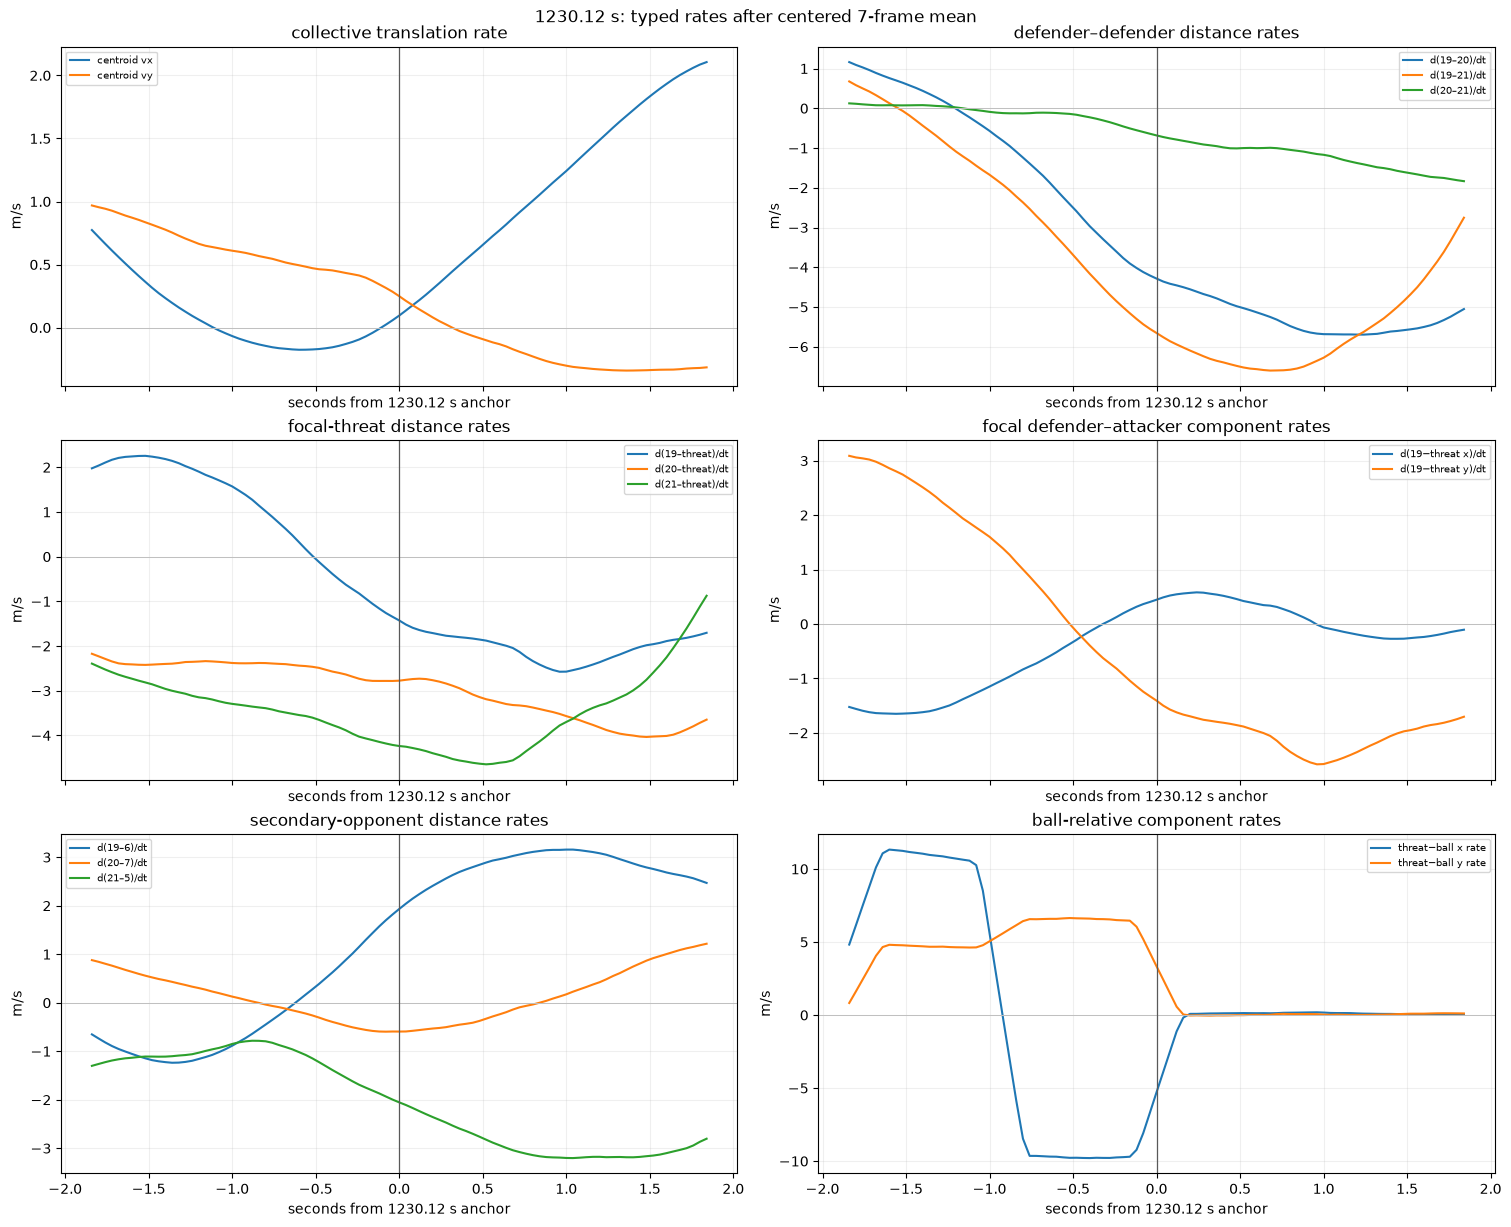

In [7]:
def primary_rates(case,window=7):
    w=add_base(case); dt,ot=case['def_team'],case['opp_team']; t=w['plot_t']; defs=case['display_defs']; time=w['Time [s]']
    fig,axes=plt.subplots(3,2,figsize=(15,12),sharex=True,constrained_layout=True)
    ax=axes[0,0]
    for col,label in [('centroid_x_m','centroid vx'),('centroid_y_m','centroid vy')]: _,r=smooth_rate(w[col],time,window); ax.plot(t,r,label=label)
    ax.set_title('collective translation rate'); ax.set_ylabel('m/s')
    ax=axes[0,1]
    for p,q in itertools.combinations(defs,2):
        d=np.hypot((w[f'{dt}_{p}_x']-w[f'{dt}_{q}_x'])*LENGTH,(w[f'{dt}_{p}_y']-w[f'{dt}_{q}_y'])*WIDTH); _,r=smooth_rate(d,time,window); ax.plot(t,r,label=f'd({p}–{q})/dt')
    ax.set_title('defender–defender distance rates'); ax.set_ylabel('m/s')
    ax=axes[1,0]
    for p in defs:
        d=np.hypot((w[f'{dt}_{p}_x']-w[f'{ot}_{case["opponent"]}_x'])*LENGTH,(w[f'{dt}_{p}_y']-w[f'{ot}_{case["opponent"]}_y'])*WIDTH); _,r=smooth_rate(d,time,window); ax.plot(t,r,label=f'd({p}–threat)/dt')
    ax.set_title('focal-threat distance rates'); ax.set_ylabel('m/s')
    ax=axes[1,1]; p=case['focal']
    for axis,scale in [('x',LENGTH),('y',WIDTH)]:
        rel=(w[f'{dt}_{p}_{axis}']-w[f'{ot}_{case["opponent"]}_{axis}'])*scale; _,r=smooth_rate(rel,time,window); ax.plot(t,r,label=f'd({p}−threat {axis})/dt')
    ax.set_title('focal defender–attacker component rates'); ax.set_ylabel('m/s')
    ax=axes[2,0]
    for p,a in zip(defs,case['secondary_opponents']):
        d=np.hypot((w[f'{dt}_{p}_x']-w[f'{ot}_{a}_x'])*LENGTH,(w[f'{dt}_{p}_y']-w[f'{ot}_{a}_y'])*WIDTH); _,r=smooth_rate(d,time,window); ax.plot(t,r,label=f'd({p}–{a})/dt')
    ax.set_title('secondary-opponent distance rates'); ax.set_ylabel('m/s')
    ax=axes[2,1]; bx=w[f'{dt}_ball_x']*LENGTH; by=w[f'{dt}_ball_y']*WIDTH
    for values,label in [(w[f'{ot}_{case["opponent"]}_x']*LENGTH-bx,'threat−ball x rate'),(w[f'{ot}_{case["opponent"]}_y']*WIDTH-by,'threat−ball y rate')]: _,r=smooth_rate(values,time,window); ax.plot(t,r,label=label)
    ax.set_title('ball-relative component rates'); ax.set_ylabel('m/s')
    for ax in axes.flat:
        ax.axhline(0,c='0.75',lw=.7); ax.axvline(0,c='0.35',lw=.9); ax.grid(alpha=.2); ax.legend(fontsize=7); ax.set_xlabel('seconds from 1230.12 s anchor')
    fig.suptitle(f'1230.12 s: typed rates after centered {window}-frame mean',y=1.01); plt.show()
primary_rates(PRIMARY,7)

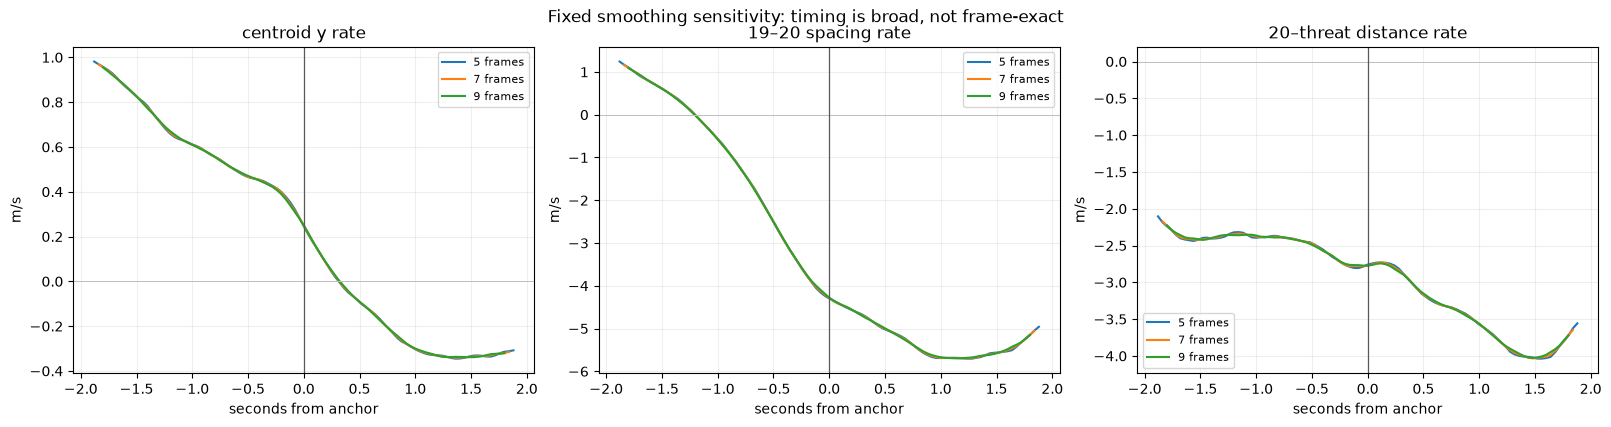

In [8]:
def sensitivity_plot(case):
    w=add_base(case); dt,ot=case['def_team'],case['opp_team']; t=w['plot_t']; time=w['Time [s]']; defs=case['display_defs']
    dd=np.hypot((w[f'{dt}_{defs[0]}_x']-w[f'{dt}_{defs[1]}_x'])*LENGTH,(w[f'{dt}_{defs[0]}_y']-w[f'{dt}_{defs[1]}_y'])*WIDTH)
    threat=np.hypot((w[f'{dt}_{defs[1]}_x']-w[f'{ot}_{case["opponent"]}_x'])*LENGTH,(w[f'{dt}_{defs[1]}_y']-w[f'{ot}_{case["opponent"]}_y'])*WIDTH)
    series=[(w['centroid_y_m'],'centroid y rate'),(dd,f'{defs[0]}–{defs[1]} spacing rate'),(threat,f'{defs[1]}–threat distance rate')]
    fig,axes=plt.subplots(1,3,figsize=(16,4),sharex=True,constrained_layout=True)
    for ax,(values,title) in zip(axes,series):
        for window in [5,7,9]: _,rate=smooth_rate(values,time,window); ax.plot(t,rate,label=f'{window} frames')
        ax.axhline(0,c='0.75',lw=.7); ax.axvline(0,c='0.35',lw=.9); ax.set(title=title,xlabel='seconds from anchor',ylabel='m/s'); ax.grid(alpha=.2); ax.legend(fontsize=8)
    fig.suptitle('Fixed smoothing sensitivity: timing is broad, not frame-exact',y=1.03); plt.show()
sensitivity_plot(PRIMARY)

### Primary-case temporal reading

The temporal view supports a typed description without a discrete state label:

- Away20 and Away21 are already reducing distance to Home10 before the reception anchor, while Away19 initially separates and then reverses toward Home10 later in the window.
- Defender–defender distances begin contracting at different times. Away19–Away20 and Away19–Away21 expand slightly early, then contract strongly; Away20–Away21 changes less at first and contracts later. Local compression therefore develops rather than appearing as an instantaneous switch.
- Away19's opponent-relative x/y path reverses direction during the approach, while the other two defenders continue on different paths. Opposing player directions and changing pair geometry coexist with limited centroid movement near the anchor.
- Selected secondary-opponent relationships move in different directions and at different times rather than showing a single uniform redistribution.
- Ball-relative components change substantially around the same interval, so ball motion remains a plausible shared driver. The typed channels are not independent causes.

The 5/7/9-frame sensitivity retains the broad direction changes but shifts and rounds local extrema. Ordering is therefore supportable only at a coarse sub-second-to-second visual scale. It is not robust enough for frame-exact precedence, optimized lags, or causal narration.

## Cross-case temporal comparison

Each case below retains raw trajectories, raw relational levels, and separate 7-frame derivative channels. The panels are repeated rather than collapsed so a qualitative comparison cannot silently become a score.

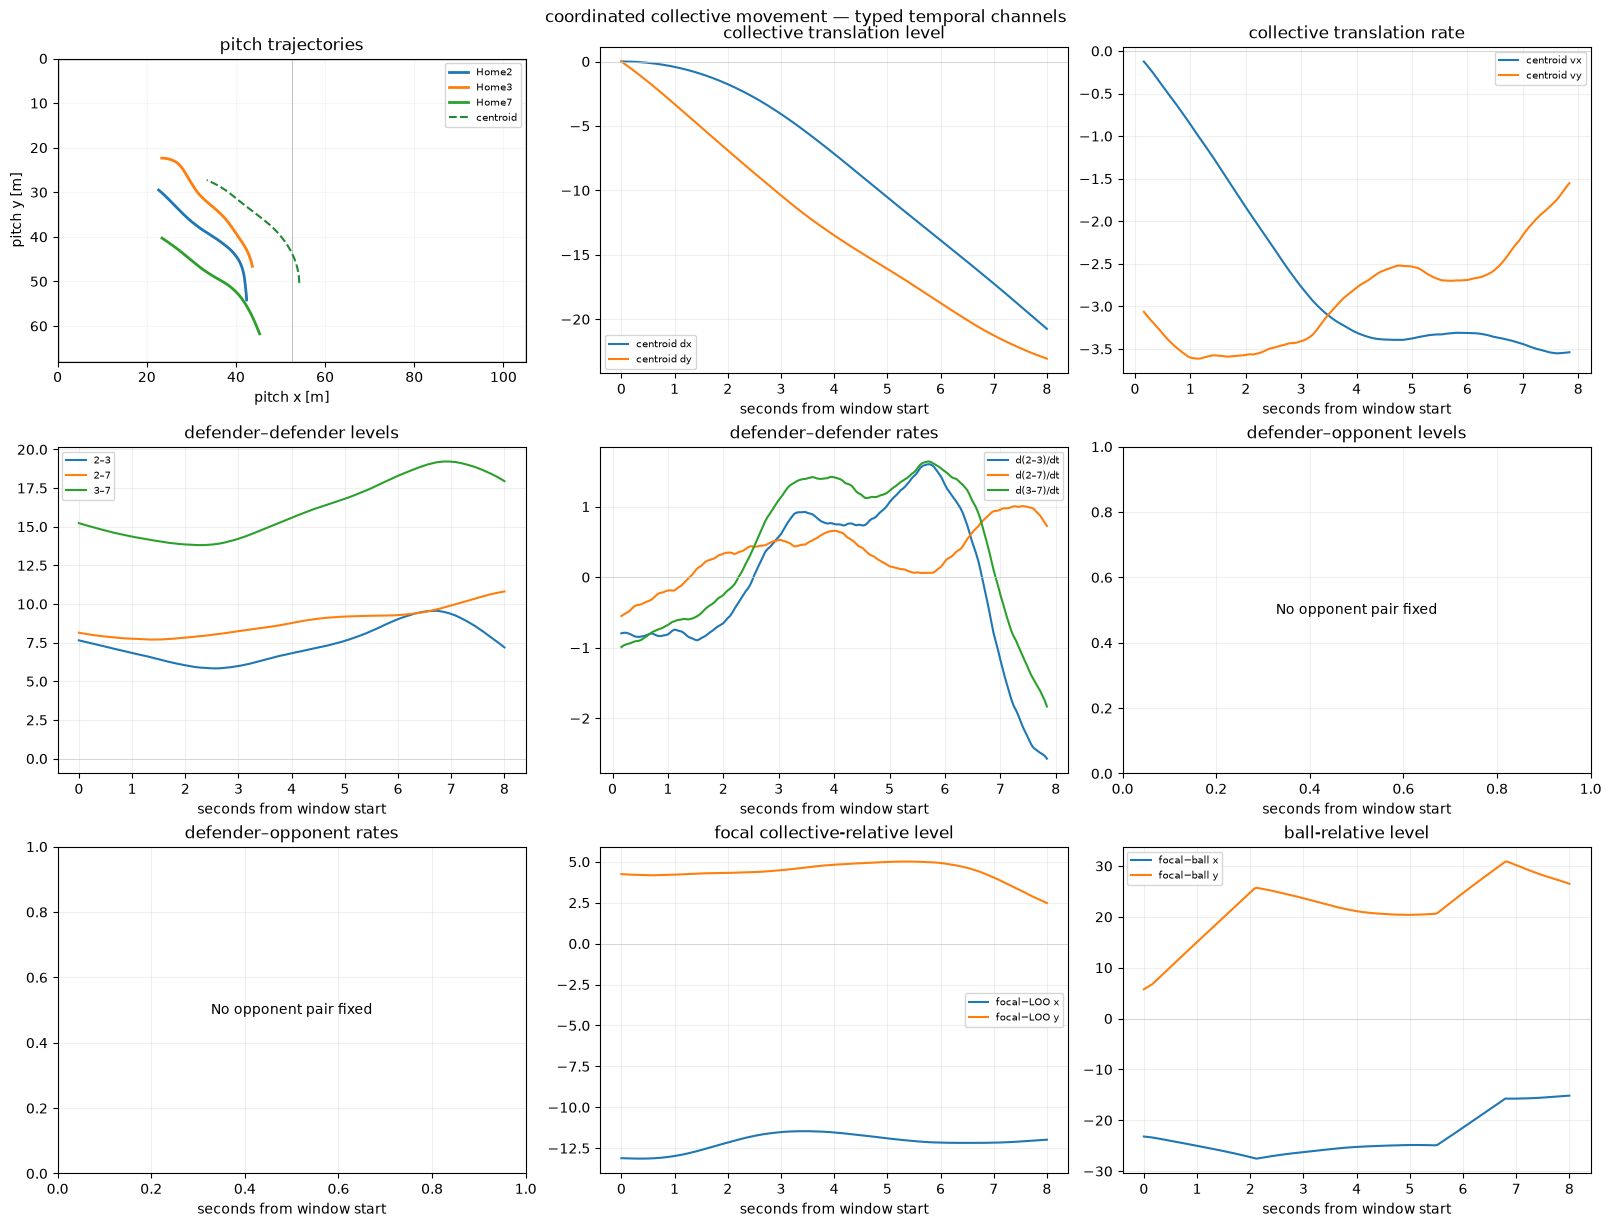

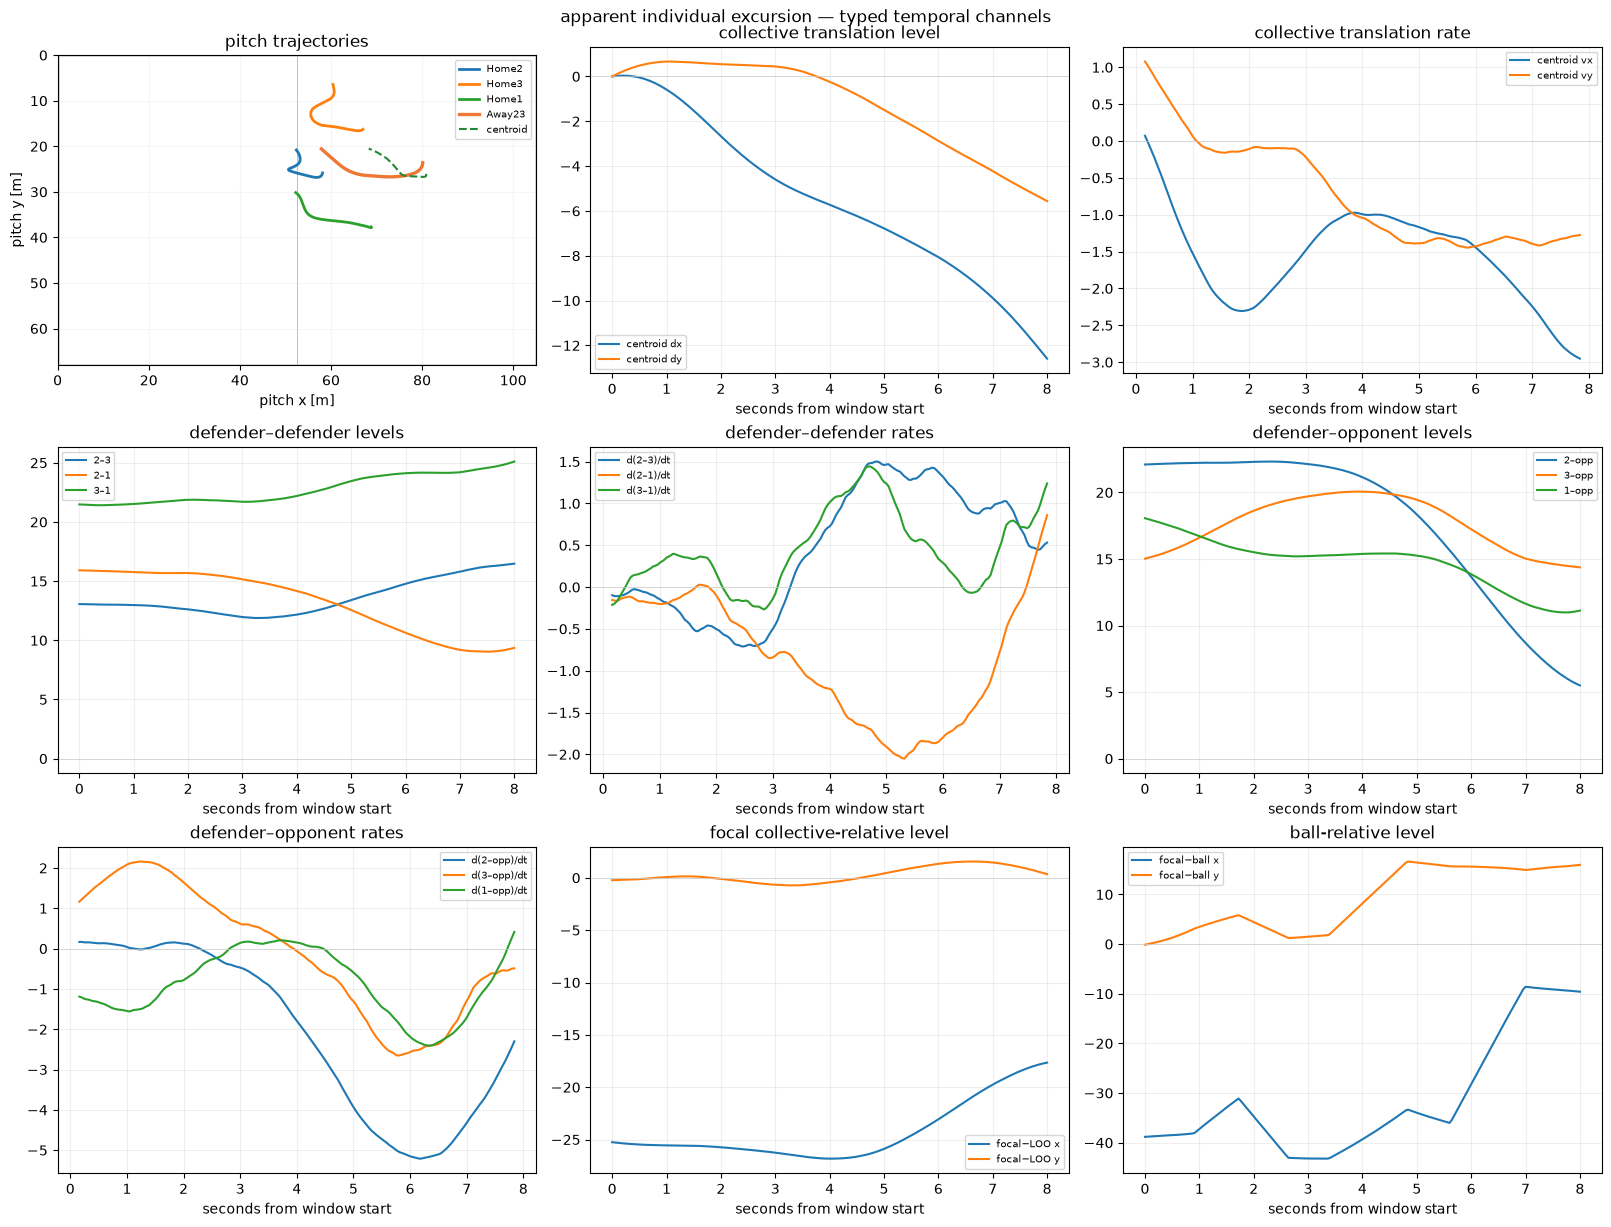

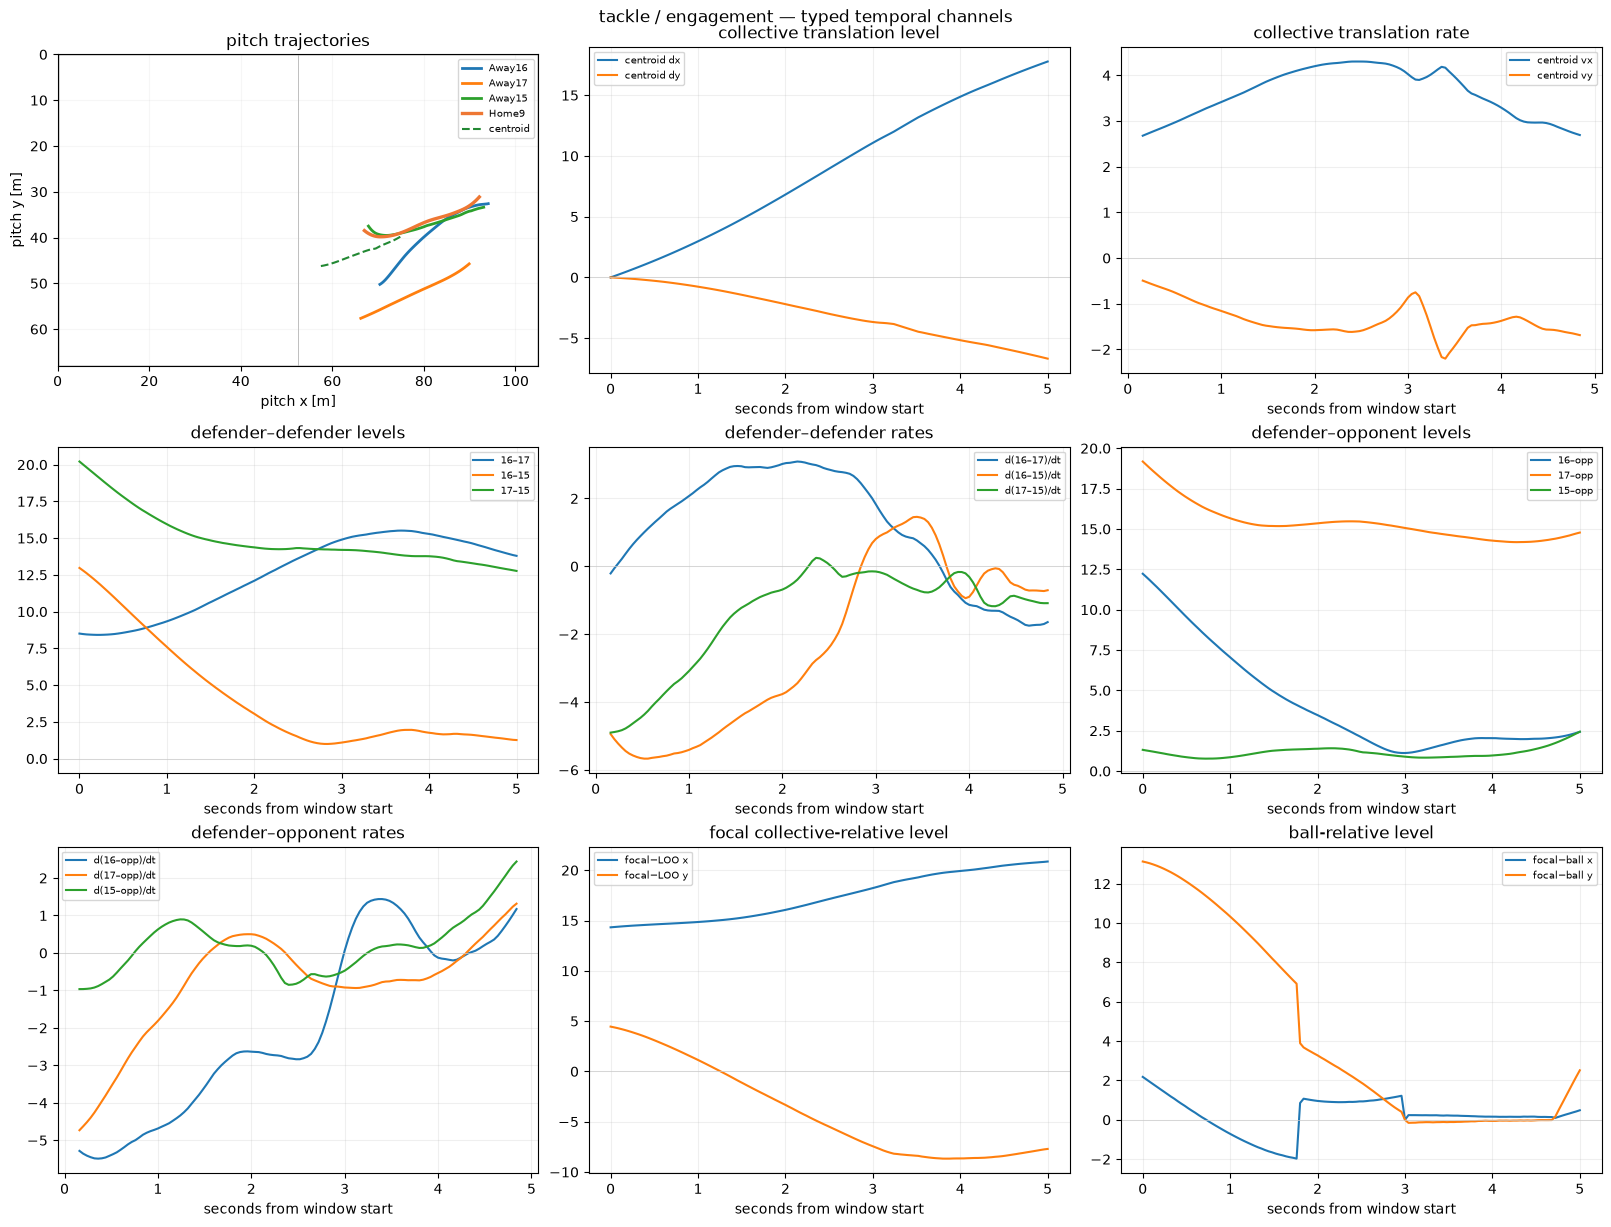

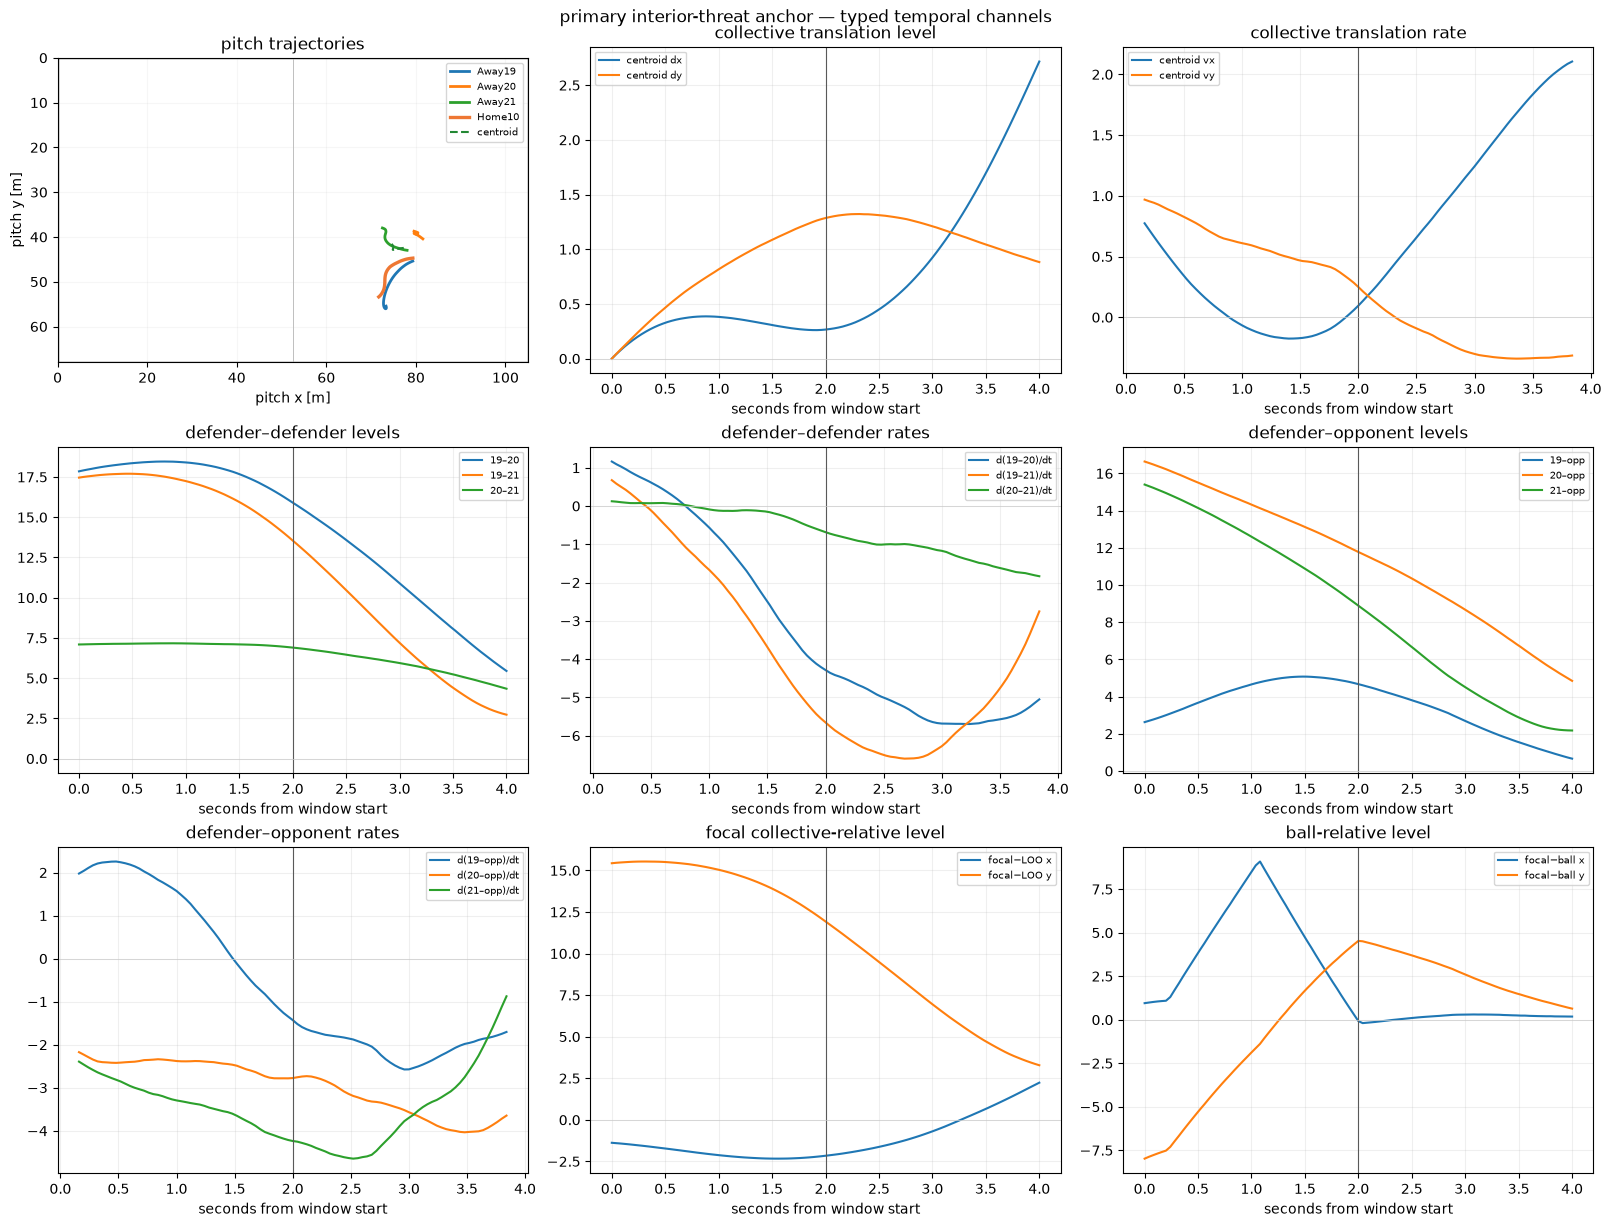

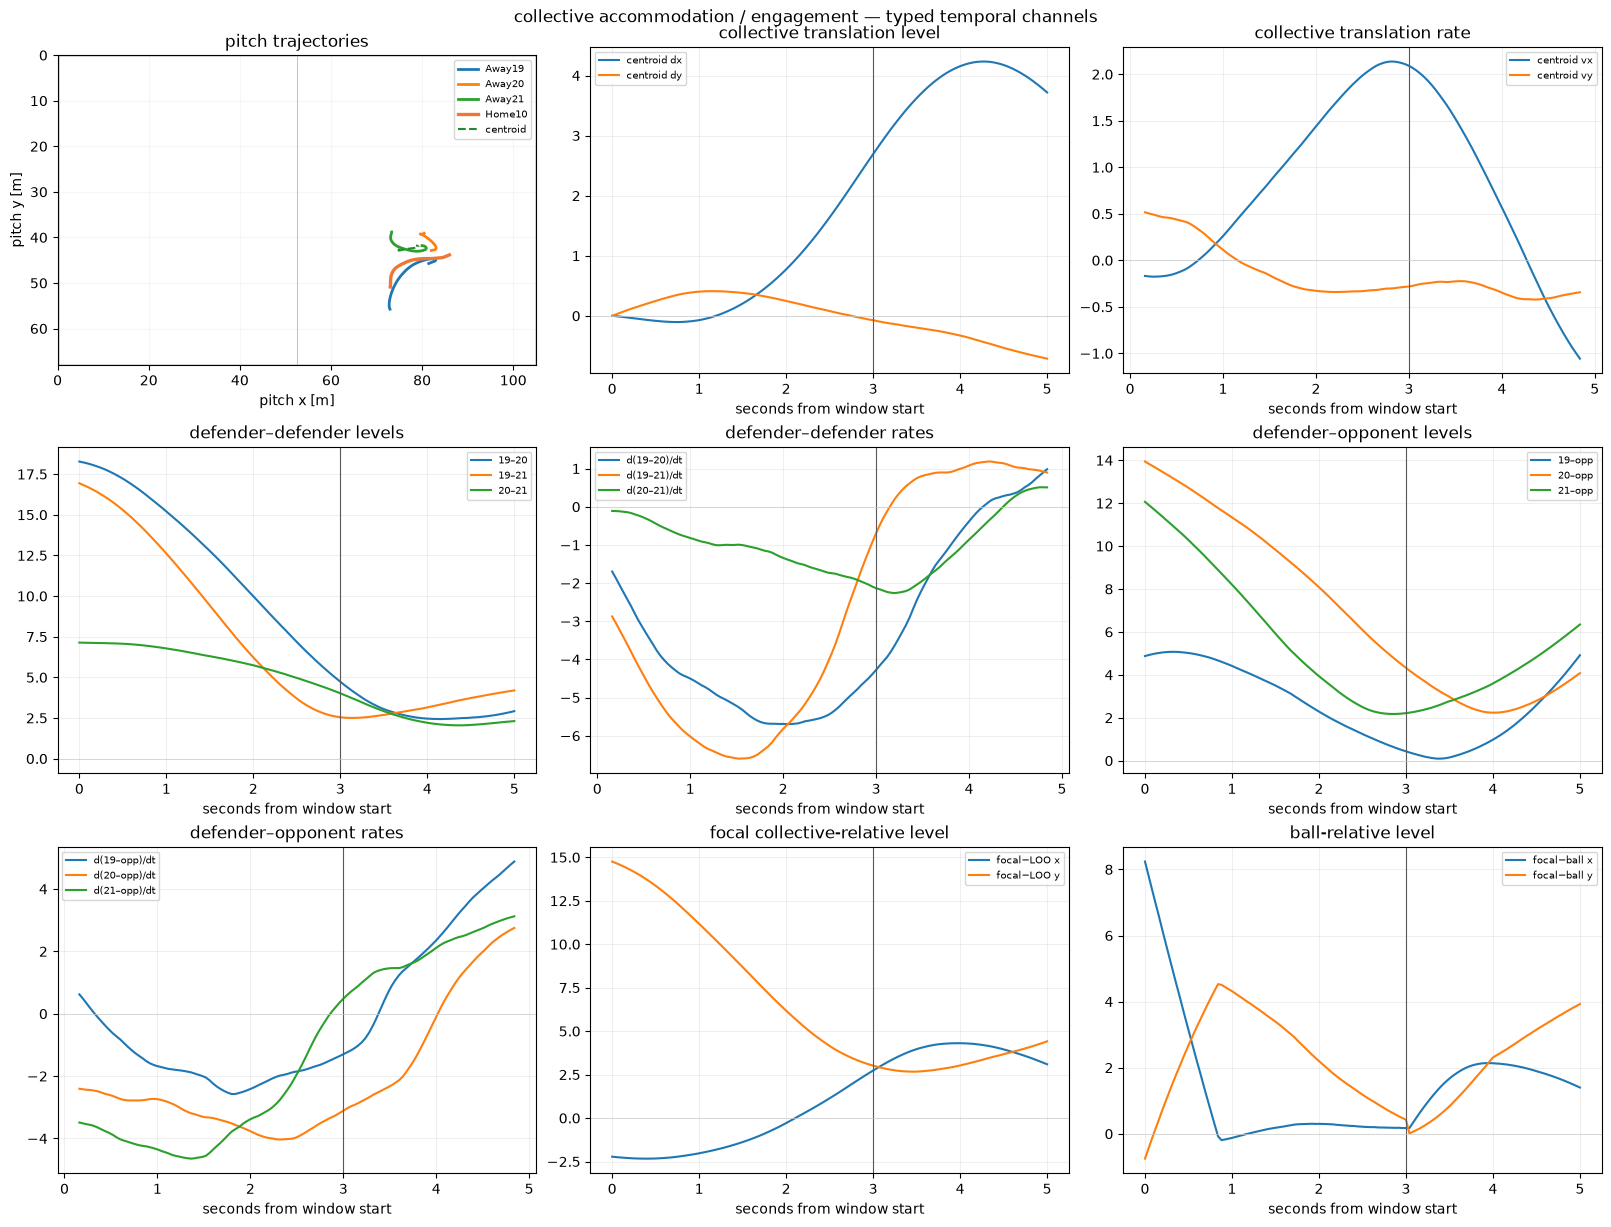

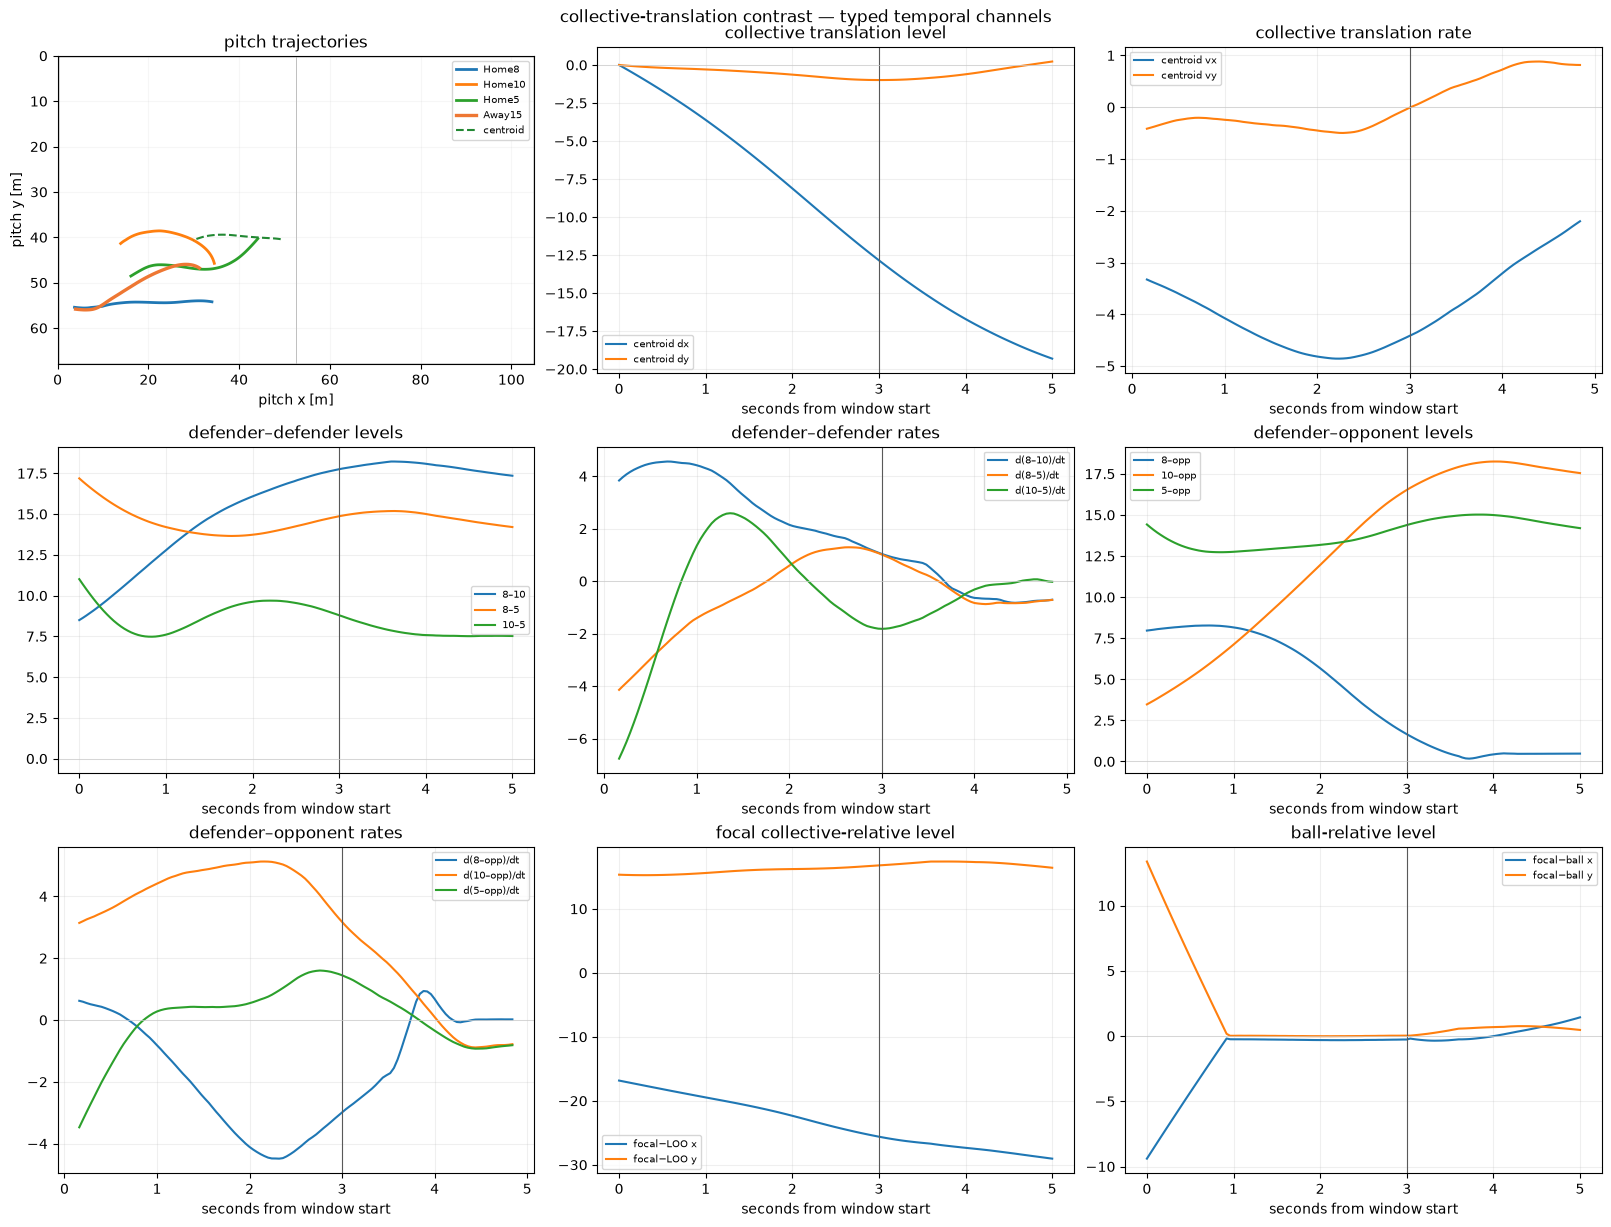

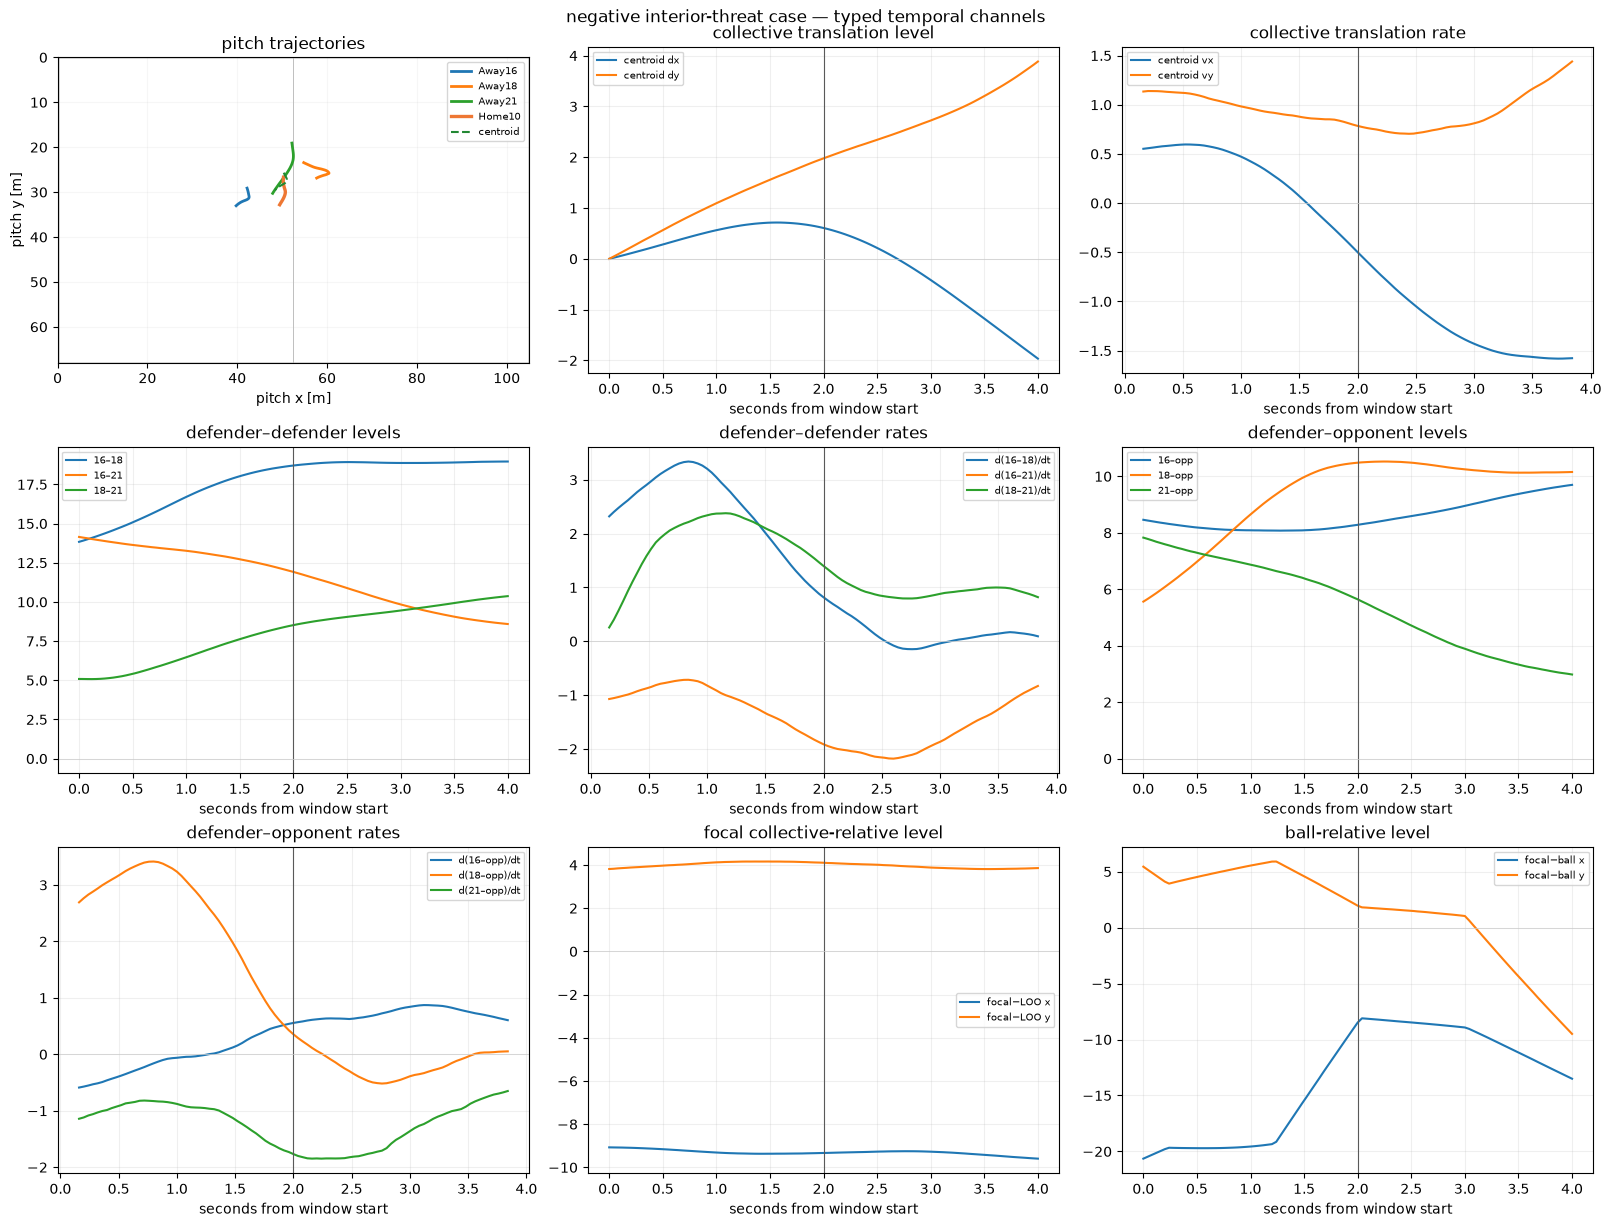

In [9]:
def cross_case_panels(case):
    w=add_base(case); dt,ot=case['def_team'],case['opp_team']; defs=case['display_defs']; time=w['Time [s]']; t=time-time.iloc[0]
    fig,axes=plt.subplots(3,3,figsize=(16,12),constrained_layout=True)
    ax=axes[0,0]; pitch(ax)
    for p in defs: ax.plot(w[f'{dt}_{p}_x']*LENGTH,w[f'{dt}_{p}_y']*WIDTH,lw=2,label=f'{dt}{p}')
    if case['opponent']: ax.plot(w[f'{ot}_{case["opponent"]}_x']*LENGTH,w[f'{ot}_{case["opponent"]}_y']*WIDTH,c='#ee7733',lw=2.4,label=f'{ot}{case["opponent"]}')
    ax.plot(w.centroid_x_m,w.centroid_y_m,c='#228833',ls='--',label='centroid'); ax.set_title('pitch trajectories'); ax.legend(fontsize=7)
    ax=axes[0,1]; ax.plot(t,w.centroid_x_m-w.centroid_x_m.iloc[0],label='centroid dx'); ax.plot(t,w.centroid_y_m-w.centroid_y_m.iloc[0],label='centroid dy'); ax.set_title('collective translation level')
    ax=axes[0,2]
    for col,label in [('centroid_x_m','centroid vx'),('centroid_y_m','centroid vy')]: _,r=smooth_rate(w[col],time,7); ax.plot(t,r,label=label)
    ax.set_title('collective translation rate')
    ax=axes[1,0]
    for p,q in itertools.combinations(defs,2):
        d=np.hypot((w[f'{dt}_{p}_x']-w[f'{dt}_{q}_x'])*LENGTH,(w[f'{dt}_{p}_y']-w[f'{dt}_{q}_y'])*WIDTH); ax.plot(t,d,label=f'{p}–{q}')
    ax.set_title('defender–defender levels')
    ax=axes[1,1]
    for p,q in itertools.combinations(defs,2):
        d=np.hypot((w[f'{dt}_{p}_x']-w[f'{dt}_{q}_x'])*LENGTH,(w[f'{dt}_{p}_y']-w[f'{dt}_{q}_y'])*WIDTH); _,r=smooth_rate(d,time,7); ax.plot(t,r,label=f'd({p}–{q})/dt')
    ax.set_title('defender–defender rates')
    ax=axes[1,2]
    if case['opponent']:
        for p in defs:
            d=np.hypot((w[f'{dt}_{p}_x']-w[f'{ot}_{case["opponent"]}_x'])*LENGTH,(w[f'{dt}_{p}_y']-w[f'{ot}_{case["opponent"]}_y'])*WIDTH); ax.plot(t,d,label=f'{p}–opp')
    else: ax.text(.5,.5,'No opponent pair fixed',ha='center',va='center',transform=ax.transAxes)
    ax.set_title('defender–opponent levels')
    ax=axes[2,0]
    if case['opponent']:
        for p in defs:
            d=np.hypot((w[f'{dt}_{p}_x']-w[f'{ot}_{case["opponent"]}_x'])*LENGTH,(w[f'{dt}_{p}_y']-w[f'{ot}_{case["opponent"]}_y'])*WIDTH); _,r=smooth_rate(d,time,7); ax.plot(t,r,label=f'd({p}–opp)/dt')
    else: ax.text(.5,.5,'No opponent pair fixed',ha='center',va='center',transform=ax.transAxes)
    ax.set_title('defender–opponent rates')
    ax=axes[2,1]; ax.plot(t,w.focal_loo_x_m,label='focal−LOO x'); ax.plot(t,w.focal_loo_y_m,label='focal−LOO y'); ax.set_title('focal collective-relative level')
    ax=axes[2,2]; bx=w[f'{dt}_ball_x']*LENGTH; by=w[f'{dt}_ball_y']*WIDTH
    ax.plot(t,w[f'{dt}_{case["focal"]}_x']*LENGTH-bx,label='focal−ball x'); ax.plot(t,w[f'{dt}_{case["focal"]}_y']*WIDTH-by,label='focal−ball y'); ax.set_title('ball-relative level')
    anchor_rel=(case.get('anchor')-case['start']) if case.get('anchor') is not None else None
    for ax in axes.flat:
        if ax is not axes[0,0]:
            if anchor_rel is not None: ax.axvline(anchor_rel,c='0.35',lw=.8)
            ax.axhline(0,c='0.8',lw=.5); ax.set_xlabel('seconds from window start'); ax.grid(alpha=.2)
        h,l=ax.get_legend_handles_labels()
        if h: ax.legend(fontsize=7)
    fig.suptitle(f"{case['name']} — typed temporal channels",y=1.01); plt.show()

for case in CASES: cross_case_panels(case)

## Qualitative cross-case findings

- **Coordinated collective movement (1888–1896s):** absolute positions and centroid components change greatly. The displayed internal distances change more slowly and less uniformly than the centroid path, although they are not constant. This is comparatively coherent translation, not rigid-shape preservation.
- **Apparent excursion (590–598s):** focal centroid-relative x and the Home2–Away23 relationship change strongly while the displayed defender–defender neighborhood is comparatively stable. Ball-relative change is also large, preserving ball response as an alternative.
- **Tackle/engagement (550.76–555.76s):** opponent convergence, local contraction, and substantial collective translation overlap. Their onsets are too entangled for a confident ordering claim.
- **Accommodation/engagement (1229.28–1234.28s):** local defender spacing contracts strongly, while focal opponent distance is non-monotonic and ends near its starting level. The temporal path reveals reorganization that an endpoint comparison would miss.
- **Collective-translation contrast (3679.88–3684.88s):** centroid translation dominates one pitch component, but focal collective-relative and opponent-relative changes remain visible. Collective motion is a large contributor, not a complete description.
- **Negative/heterogeneous case (4195.04–4199.04s):** focal centroid-relative position is stable, one defender approaches Home10, another separates, and defender–defender spacings move in opposing directions. The typed display distinguishes this from the broadly convergent 1230.12s case without a score, but does not reduce it to one coherent narrative.

Some channels reproduce shared underlying movement—especially centroid and ball-relative changes during large translations—but they are not duplicates in the anchor, excursion, accommodation, or negative cases. Ball movement explains substantial context in several windows and prevents opponent-relative change from being read as opponent-specific intent.

## Temporal ordering and failure questions

Broad temporal ordering is visually plausible in the 1230.12s anchor: Away20/Away21 threat convergence begins before the event anchor; Away19 reverses later; strong local compression develops across the window; and secondary-opponent channels change heterogeneously. The accommodation window also shows why endpoint comparisons are insufficient. However, 5/7/9-frame sensitivity and continuous curved movement make precise onset times unstable. The evidence supports “relationships changed with partially staggered timing,” not a frame-exact sequence or causal chain.

Failure checks:

- **Too noisy?** Raw 25 Hz first differences are too noisy for direct interpretation; the fixed short smoothing makes broad trends readable but does not license exact onset estimates.
- **Same movement repeated?** Some channels share collective or ball-driven motion, but local and opponent channels diverge materially in the anchor and negative controls.
- **Ball explains everything?** No, but ball-relative movement is often large enough that opponent-specific interpretations remain underdetermined.
- **Can 4197.04s be distinguished without a score?** Qualitatively yes: its typed channels are mixed rather than jointly compressive. This is a descriptive contrast, not a classification rule.
- **Are narratives being imposed?** This remains a serious risk. Ordering is clearest only at a broad scale, varies with the relationship selected, and is not robust enough for automated lead–lag claims.

## Implication for “defensive relational reallocation”

The construct is feasible in a limited descriptive sense: a relational configuration can be watched changing through typed geometric channels, and the 1230.12s sequence is not merely a persuasive before/after contrast. Different relationships change in different directions and with partially staggered timing while centroid motion remains limited. “Reallocation” should therefore mean an interpretable temporal reconfiguration of preserved relationship types—not transfer of a zero-sum weight, not a discrete state transition, and not a single magnitude.

The diagnostic does not yet establish reliable onset detection, generality, causal order, or a complete representation. No composite score, relational weights, gravity/style metric, structure/exposure score, assignment inference, state classifier, change-point algorithm, optimized threshold or lag, clustering, network, HMM, ML, causal inference, or dataset expansion is introduced. Phase 2B stops here.